# PREDICTION OF SOLUBILITY PARAMETERS

Version 1  
Sept 2026    
TI-Coast  
John Mommers     



## 1 Define ML application

**Goal of this ML model:**  
The script takes a molecule represented as a SMILES string, converts that molecular structure into features that a machine-learning algorithm can use, and then predicts the Abraham's Solubility Parameters

> X = SMILES --> features  
> y = Abraham's Solubility Parameters     


**Information about the dataset**  
Abraham's solubility parameters, often referred to as the Abraham solvation parameter model, provide a quantitative description of solute-solvent interactions. These parameters are a set of six descriptors (E, S, A, B, V, L) that characterize the physical and chemical properties of a molecule. Each parameter represents a specific type of interaction:

>- E (Excess Molar Refraction): Relates to the electron lone pair interactions and polarizability of the molecule.  
>- S (Dipolarity/Polarizability): Represents the ability of a molecule to act as a dipole and its polarizability.  
>- A (Hydrogen Bond Acidity): Quantifies the molecule's ability to donate a hydrogen bond.  
>- B (Hydrogen Bond Basicity): Quantifies the molecule's ability to accept a hydrogen bond.  
>- V (Characteristic Volume): Represents the McGowan characteristic volume of the molecule, related to its size and volume.
>- L (Logarithm of the Hexadecane-Air Partition Coefficient): Describes the dispersion interactions and overall hydrophobicity/lipophilicity of the molecule.  

By knowing these parameters for a solute and a solvent, it's possible to predict a wide range of physicochemical properties, including solubility, partition coefficients, and chromatographic retention, through linear free energy relationships (LFERs). These models are widely used in chemistry, pharmacy, and environmental science for understanding and predicting molecular behavior in various systems.



## 2 Load data

In [ ]:
import pandas as pd

df_raw = pd.read_pickle('/content/drive/MyDrive/Abraham/abraham_unique.pkl')

df = df_raw[
    [
        "Canonical_SMILES",
        "E",
        "S",
        "A",
        "B",
        "V",
        "L"
    ]
].copy()
df

,Canonical_SMILES,E,S,A,B,V,L
0,BrC(Br)(Br)Br,1.190000,0.940000,0.000000,0.000000,0.9495,4.557000
1,BrC(Br)(Br)C(Br)(Br)Br,1.478320,1.228869,0.000000,0.378440,1.4404,6.991041
2,BrC(Br)=C(Br)Br,1.357524,1.126026,0.000000,0.226954,1.0474,5.566140
3,BrC(Br)Br,0.968335,0.683996,0.150494,0.068095,0.7745,3.778181
4,BrC(Br)C(Br)Br,1.333433,0.927514,0.153461,0.193453,1.0904,5.603037
...,...,...,...,...,...,...,...
8132,c1ccc2nc3ccccc3cc2c1,2.379500,1.321875,0.000450,0.574291,1.4133,7.592989
8133,c1ccc2nnccc2c1,1.333333,1.433333,0.000000,0.653333,1.0032,5.886356
8134,c1ccc2oc(CSCc3nc4ccccc4o3)nc2c1,2.730000,2.080000,0.000000,1.000000,2.0651,11.920000
8135,c1cnc2c(c1)CCC2,1.020000,0.905000,0.000000,0.530443,0.9894,4.628000


## 3 Explore, standardize and clean

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8137 entries, 0 to 8136
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Canonical_SMILES  8137 non-null   object 
 1   E                 8137 non-null   float64
 2   S                 8137 non-null   float64
 3   A                 8137 non-null   float64
 4   B                 8137 non-null   float64
 5   V                 8137 non-null   float64
 6   L                 8137 non-null   float64
dtypes: float64(6), object(1)
memory usage: 445.1+ KB


### Histograms of Abraham's Solubility Parameters

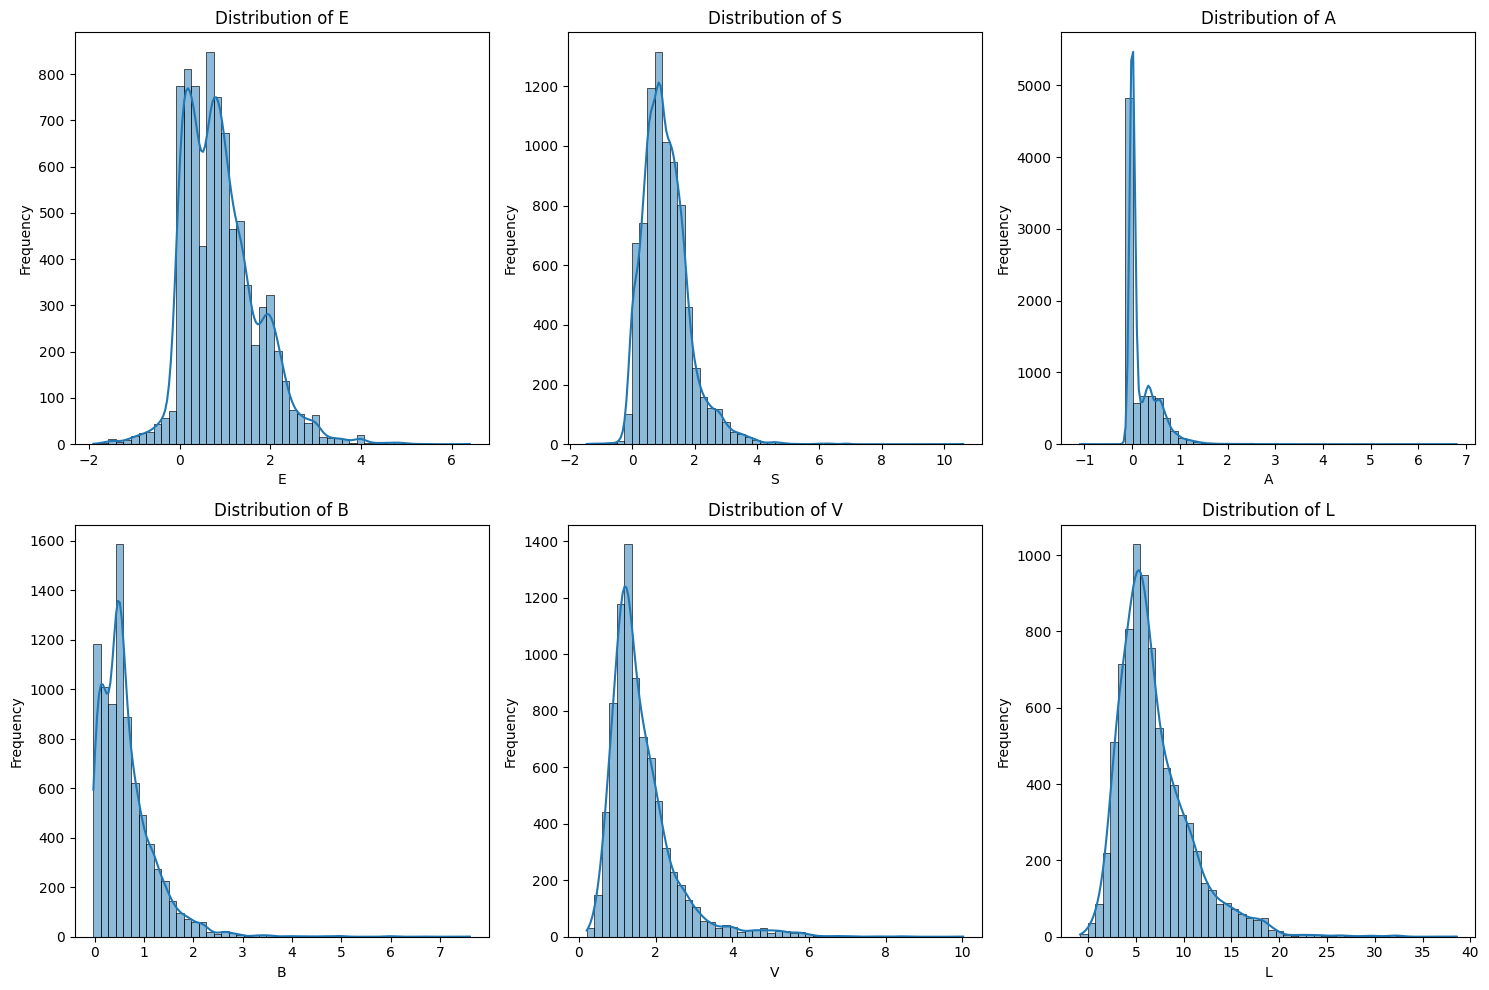

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

abraham_parameters = ['E', 'S', 'A', 'B', 'V', 'L']

plt.figure(figsize=(15, 10))
for i, param in enumerate(abraham_parameters):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.histplot(df[param], bins=50, kde=True)
    plt.title(f'Distribution of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 4 Featurization

In [ ]:
! pip install rdkit

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def generate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    # Generate a set of common molecular descriptors
    descriptor_names = [
        'MolWt', 'MolLogP', 'MolMR', 'NumHDonors', 'NumHAcceptors',
        'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings',
        'FractionCSP3', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'RingCount',
        'TPSA', 'ExactMolWt'
    ]
    descriptors = {name: getattr(Descriptors, name)(mol) for name in descriptor_names}
    return descriptors

# Apply the function to the SMILES column
df['Descriptors'] = df['Canonical_SMILES'].apply(generate_descriptors)

# Expand the dictionary of descriptors into separate columns
df = pd.concat([df.drop('Descriptors', axis=1), df['Descriptors'].apply(pd.Series)], axis=1)

print("Molecular descriptors generated and added to the DataFrame.")
df

Molecular descriptors generated and added to the DataFrame.


,Canonical_SMILES,E,S,A,B,V,L,MolWt,MolLogP,MolMR,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,RingCount,TPSA,ExactMolWt
0,BrC(Br)(Br)Br,1.190000,0.940000,0.000000,0.000000,0.9495,4.557000,331.627,3.1773,38.439,...,0.0,32.0,0.0,1.000000,5.0,0.0,0.0,0.0,0.00,327.673348
1,BrC(Br)(Br)C(Br)(Br)Br,1.478320,1.228869,0.000000,0.378440,1.4404,6.991041,503.446,4.6634,59.024,...,0.0,50.0,0.0,1.000000,8.0,0.0,0.0,0.0,0.00,497.510023
2,BrC(Br)=C(Br)Br,1.357524,1.126026,0.000000,0.226954,1.0474,5.566140,343.638,3.6926,42.734,...,0.0,36.0,0.0,0.000000,6.0,0.0,0.0,0.0,0.00,339.673348
3,BrC(Br)Br,0.968335,0.683996,0.150494,0.068095,0.7745,3.778181,252.731,2.4547,30.569,...,0.0,26.0,0.0,1.000000,4.0,0.0,0.0,0.0,0.00,249.762836
4,BrC(Br)C(Br)Br,1.333433,0.927514,0.153461,0.193453,1.0904,5.603037,345.654,3.2182,43.284,...,1.0,38.0,0.0,1.000000,6.0,0.0,0.0,0.0,0.00,341.688998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8132,c1ccc2nc3ccccc3cc2c1,2.379500,1.321875,0.000450,0.574291,1.4133,7.592989,179.222,3.3880,59.249,...,0.0,66.0,3.0,0.000000,14.0,0.0,1.0,3.0,12.89,179.073499
8133,c1ccc2nnccc2c1,1.333333,1.433333,0.000000,0.653333,1.0032,5.886356,130.150,1.6298,39.538,...,0.0,48.0,2.0,0.000000,10.0,0.0,2.0,2.0,25.78,130.053098
8134,c1ccc2oc(CSCc3nc4ccccc4o3)nc2c1,2.730000,2.080000,0.000000,1.000000,2.0651,11.920000,296.351,4.4024,83.017,...,4.0,104.0,4.0,0.125000,21.0,0.0,4.0,4.0,52.06,296.061949
8135,c1cnc2c(c1)CCC2,1.020000,0.905000,0.000000,0.530443,0.9894,4.628000,119.167,1.5703,36.262,...,0.0,46.0,1.0,0.375000,9.0,0.0,1.0,2.0,12.89,119.073499


In [ ]:
from sklearn.model_selection import train_test_split

# Define feature columns (X) based on generated molecular descriptors
feature_columns = [
    'MolWt', 'MolLogP', 'MolMR', 'NumHDonors', 'NumHAcceptors',
    'NumRotatableBonds', 'NumValenceElectrons', 'NumAromaticRings',
    'FractionCSP3', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'RingCount',
    'TPSA', 'ExactMolWt'
]
X = df[feature_columns]
# Remove duplicate columns from X if any were created during df construction
X = X.loc[:,~X.columns.duplicated()].copy()

# Define target columns (y) as Abraham's solubility parameters
target_columns = ['E', 'S', 'A', 'B', 'V', 'L']
y = df[target_columns]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8137, 15)
y shape: (8137, 6)


## 5 Split data

In [ ]:
# Split into training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6509, 15)
X_test shape: (1628, 15)
y_train shape: (6509, 6)
y_test shape: (1628, 6)


## 5.1 Standardize Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features standardized successfully.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Features standardized successfully.
X_train_scaled shape: (6509, 15)
X_test_scaled shape: (1628, 15)


### Train-test split options

**Random split**  
The dataset is randomly divided into a training set and a test set. This is simple and useful as a baseline, but very similar molecules can end up in both sets, which may make the model performance look better than it really is.

**Stratified split (better)**  
A stratified split keeps the retention-time distribution similar in the training and test sets. Because retention time is continuous, the RT values are first divided into bins. This gives a more balanced split than a fully random split.

**Scaffold split (best)**  
A scaffold split separates molecules based on their core chemical structure. Molecules with the same or very similar scaffold are kept in the same group. This makes the test set chemically more different from the training set and gives a more realistic measure of how well the model can predict retention times for new types of molecules.

For retention-time prediction from SMILES, a scaffold split is usually the most useful final evaluation, while a random or stratified split can be used as a baseline.



## 6  Choose and built model

In [ ]:
!pip -q install xgboost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Define XGBoost model
xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
)

# Train model
xgb_model.fit(X_train, y_train)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=True,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=-1,
                                            num_parallel_tree=None, ...))

## 7 Train model

## 8 Evaluate model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate each Abraham parameter
for i, parameter in enumerate(target_columns):

    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(parameter)
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²:", round(r2, 3))
    print()

E
MAE: 0.082
RMSE: 0.142
R²: 0.971

S
MAE: 0.145
RMSE: 0.251
R²: 0.894

A
MAE: 0.055
RMSE: 0.136
R²: 0.847

B
MAE: 0.074
RMSE: 0.129
R²: 0.949

V
MAE: 0.02
RMSE: 0.045
R²: 0.997

L
MAE: 0.298
RMSE: 0.757
R²: 0.96



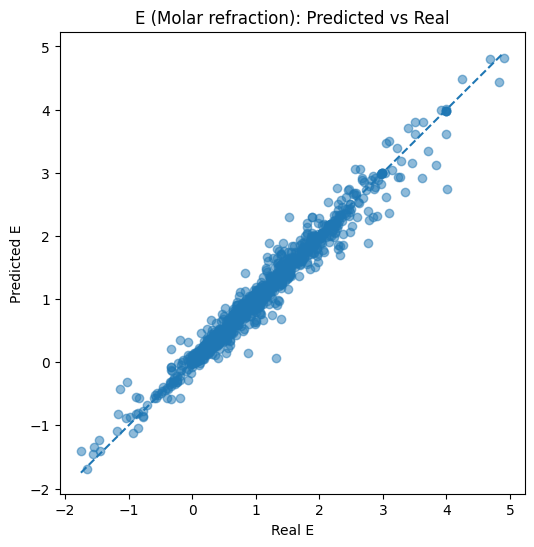

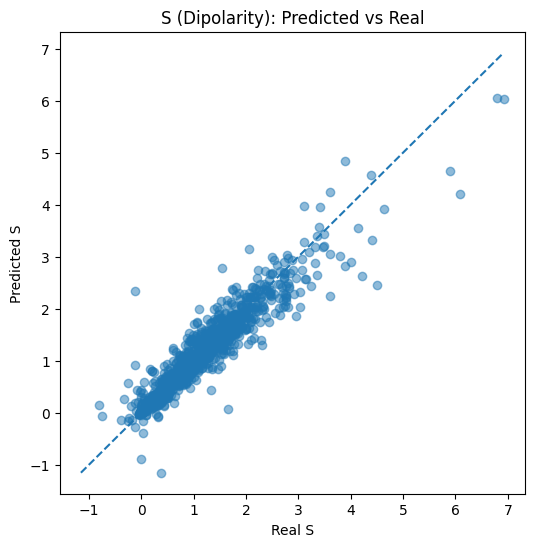

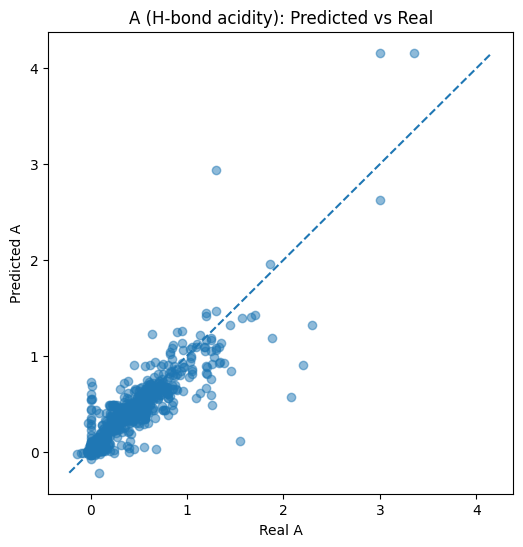

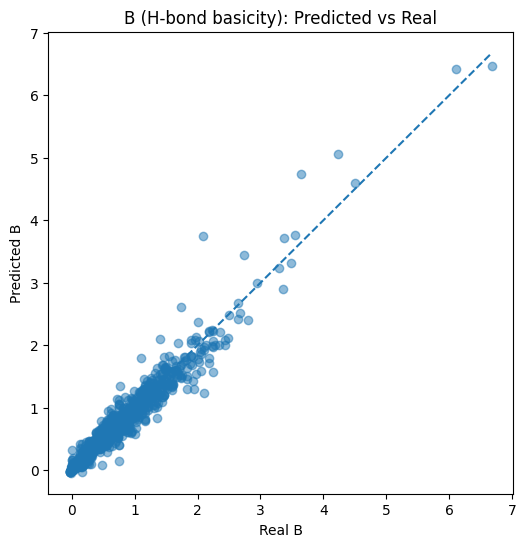

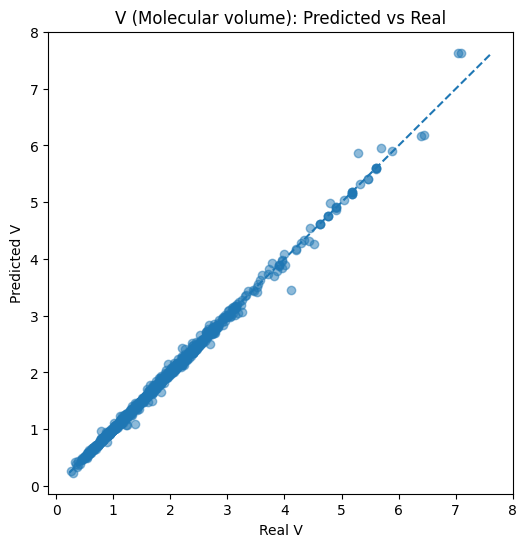

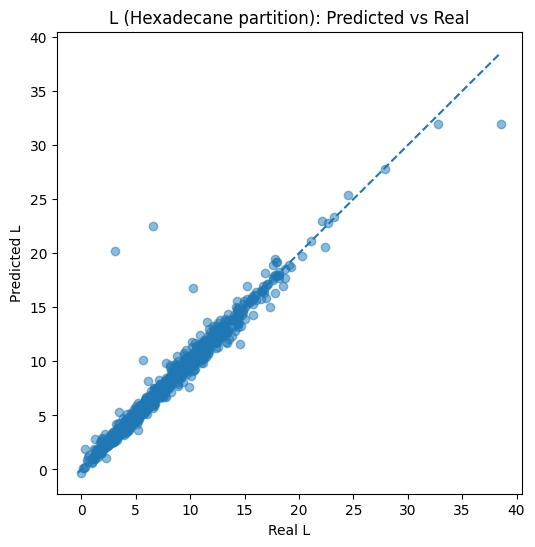

In [ ]:
import matplotlib.pyplot as plt

# Short meaning of each Abraham parameter
parameter_meaning = {
    "E": "Molar refraction",
    "S": "Dipolarity",
    "A": "H-bond acidity",
    "B": "H-bond basicity",
    "V": "Molecular volume",
    "L": "Hexadecane partition"
}

for i, parameter in enumerate(target_columns):

    plt.figure(figsize=(6, 6))

    # Real vs predicted values
    plt.scatter(
        y_test.iloc[:, i],
        y_pred[:, i],
        alpha=0.5
    )

    # Perfect prediction line
    minimum = min(y_test.iloc[:, i].min(), y_pred[:, i].min())
    maximum = max(y_test.iloc[:, i].max(), y_pred[:, i].max())

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        "--"
    )

    plt.xlabel("Real " + parameter)
    plt.ylabel("Predicted " + parameter)

    plt.title(
        parameter + " (" + parameter_meaning[parameter] + "): Predicted vs Real"
    )

    plt.show()

## 9 Save the model for re-use

In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "/content/drive/MyDrive/Abraham/abraham_xgboost.pkl"
)

['/content/drive/MyDrive/Abraham/abraham_xgboost.pkl']

In [ ]:
joblib.dump(
    {
        "features": feature_columns,
        "targets": target_columns
    },
    "/content/drive/MyDrive/Abraham/abraham_model_info.pkl"
)

['/content/drive/MyDrive/Abraham/abraham_model_info.pkl']

Load and use it in other notebooks  
Use the script below to use it in other notebooks

In [59]:
!pip -q install rdkit xgboost

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import joblib
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors


# Load trained model
model = joblib.load(
    "/content/drive/MyDrive/Abraham/abraham_xgboost.pkl"
)


# Features used during training
feature_columns = [
    "MolWt",
    "MolLogP",
    "MolMR",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "NumValenceElectrons",
    "NumAromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
    "NHOHCount",
    "NOCount",
    "RingCount",
    "TPSA",
    "ExactMolWt"
]

target_columns = ["E", "S", "A", "B", "V", "L"]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def predict_abraham(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError("Invalid SMILES")

    features = {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "MolMR": Crippen.MolMR(mol),
        "NumHDonors": Lipinski.NumHDonors(mol),
        "NumHAcceptors": Lipinski.NumHAcceptors(mol),
        "NumRotatableBonds": Lipinski.NumRotatableBonds(mol),
        "NumValenceElectrons": Descriptors.NumValenceElectrons(mol),
        "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "NHOHCount": Lipinski.NHOHCount(mol),
        "NOCount": Lipinski.NOCount(mol),
        "RingCount": Lipinski.RingCount(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "ExactMolWt": Descriptors.ExactMolWt(mol)
    }

    X = pd.DataFrame([features])[feature_columns]

    prediction = model.predict(X)[0]

    return dict(zip(target_columns, prediction))

In [ ]:
predict_abraham("CCO")

{'E': np.float32(0.23578231),
 'S': np.float32(0.43120682),
 'A': np.float32(0.34950283),
 'B': np.float32(0.48461774),
 'V': np.float32(0.44023982),
 'L': np.float32(1.6479303)}